In [1]:
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb


/Users/katiegalaeva/miniconda3/envs/catboost_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [79]:
train = pd.read_csv('train.csv')
train

,name,_id,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,last_dt,avg_reviews,total_host,target
0,Belle Harbor 4 BR 2 bath- 1 bl from Beach,40327248,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2019-07-07,2.88,1,334
1,"Come see Brooklyn, New York",13617520,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,2015-02-25,0.13,1,0
2,Large 2Br on W71st & Columbus Feb 19-28,26754726,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,NaN,NaN,1,0
3,Perfect bedroom. Near Subways Columbia CityCol...,16721721,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,2018-11-04,0.64,1,0
4,Cozy Sun Filled Fresh Guest Room in Artsy Bush...,22246463,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,2019-06-23,0.76,1,155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Manhattan Apartment - Near North Central Park,108286255,Gabrielle,Manhattan,Harlem,40.81264,-73.94231,Private room,60,1,3,2019-01-01,0.46,1,0
36667,Elegant 1876 Boerum Hill Brownstone,16395150,Patti,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,265,2,10,2016-09-07,0.18,1,0
36668,Super cute and sunny 2 bedroom,39304,Andrea,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,240,365,0,NaN,NaN,1,363
36669,TWO BIG Rooms - a Park Slope Oasis,15942513,Tom,Brooklyn,South Slope,40.66617,-73.98862,Private room,90,2,15,2019-06-18,2.34,1,91


**Обработка данных**
-Заполнение пропусков:
В функции preprocess_data заполняем пропуски в колонке host_name значением 'unknown'. Аналогично для тестовой выборки в функции preprocess_data_test заполняются пропуски в amt_reviews значением 0 и в avg_reviews значением медианы.
-Работа с датами:
Преобразуем строковое представление даты в тип datetime, рассчитываем количество дней с последнего отзыва и выделяем год и месяц последнего отзыва.
-Удаление ненужных колонок:
После формирования новых признаков удаляются колонки, которые не несут полезной информации (например, _id, name и last_dt).

In [80]:
def preprocess_data(df):

    df['host_name'].fillna('unknown', inplace=True)
    df['amt_reviews'].fillna(0, inplace=True)
    df['avg_reviews'].fillna(df['avg_reviews'].median(), inplace=True)
    
   
    df['last_dt'] = pd.to_datetime(df['last_dt'])
    df['days_since_review'] = (datetime.now() - df['last_dt']).dt.days
    df['last_review_year'] = df['last_dt'].dt.year
    df['last_review_month'] = df['last_dt'].dt.month
   
    #df['target'] = np.log1p(df['target'])  
   
    df.drop(['_id', 'name', 'last_dt'], axis=1, inplace=True)
    
    return df

In [81]:
def add_features(df, kmeans_model):
    # Здесь используем заранее обученную модель KMeans
    df['location_cluster_kmeans'] = kmeans_model.predict(df[['lat', 'lon']])
    
    # Добавляем те же признаки, что и на обучении
    df['host_listings_percent'] = df['total_host'] / df['total_host'].max()
    df['price_per_day'] = df['sum'] / (df['min_days'] + 1)
    return df

In [82]:
train = preprocess_data(train)

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_58115/81160693.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('unknown', inplace=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_58115/81160693.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always be

In [83]:
from sklearn.cluster import KMeans

# Обучаем модель на координатах тренировочного набора
coords = train[['lat', 'lon']].dropna()
kmeans_model = KMeans(n_clusters=20, random_state=42).fit(coords)

# Применяем функцию add_features для train, передавая обученную модель
train = add_features(train, kmeans_model)

In [84]:
train

,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_year,last_review_month,location_cluster_kmeans,host_listings_percent,price_per_day
0,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2.88,1,334,2096.0,2019.0,7.0,13,0.003058,116.666667
1,Howard T.,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,40,5,8,0.13,1,0,3689.0,2015.0,2.0,7,0.003058,6.666667
2,Julie,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,200,5,0,0.72,1,0,NaN,NaN,NaN,11,0.003058,33.333333
3,Federico,Manhattan,Harlem,40.81530,-73.95080,Private room,65,2,18,0.64,1,0,2341.0,2018.0,11.0,3,0.003058,21.666667
4,Lisa,Brooklyn,Bushwick,40.70230,-73.92935,Private room,99,2,26,0.76,1,155,2110.0,2019.0,6.0,2,0.003058,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Gabrielle,Manhattan,Harlem,40.81264,-73.94231,Private room,60,1,3,0.46,1,0,2283.0,2019.0,1.0,3,0.003058,30.000000
36667,Patti,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,265,2,10,0.18,1,0,3129.0,2016.0,9.0,7,0.003058,88.333333
36668,Andrea,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,240,365,0,0.72,1,363,NaN,NaN,NaN,9,0.003058,0.655738
36669,Tom,Brooklyn,South Slope,40.66617,-73.98862,Private room,90,2,15,2.34,1,91,2115.0,2019.0,6.0,7,0.003058,30.000000


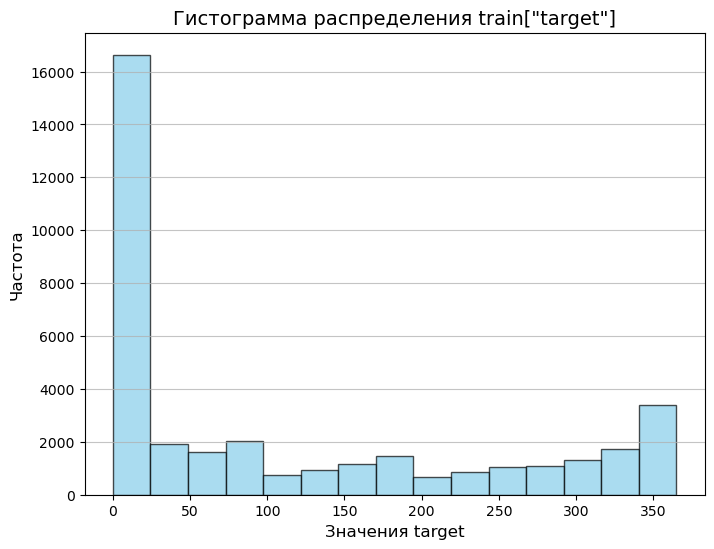

In [ ]:


plt.figure(figsize=(8, 6))
plt.hist(train['target'], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Значения target', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Гистограмма распределения train["target"]', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [98]:
#train = train.drop(columns=['host_name',	'location_cluster',	'location', 'type_house'])

In [48]:
train

,lat,lon,sum,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_year,last_review_month,location_cluster_kmeans,host_listings_percent,price_per_day
0,40.57215,-73.85822,350,2,5,2.88,1,334,2093.0,2019.0,7.0,13,0.003058,116.666667
1,40.69172,-73.96934,40,5,8,0.13,1,0,3686.0,2015.0,2.0,7,0.003058,6.666667
2,40.77673,-73.98011,200,5,0,0.72,1,0,NaN,NaN,NaN,11,0.003058,33.333333
3,40.81530,-73.95080,65,2,18,0.64,1,0,2338.0,2018.0,11.0,3,0.003058,21.666667
4,40.70230,-73.92935,99,2,26,0.76,1,155,2107.0,2019.0,6.0,2,0.003058,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,40.81264,-73.94231,60,1,3,0.46,1,0,2280.0,2019.0,1.0,3,0.003058,30.000000
36667,40.68554,-73.98471,265,2,10,0.18,1,0,3126.0,2016.0,9.0,7,0.003058,88.333333
36668,40.71852,-73.94165,240,365,0,0.72,1,363,NaN,NaN,NaN,9,0.003058,0.655738
36669,40.66617,-73.98862,90,2,15,2.34,1,91,2112.0,2019.0,6.0,7,0.003058,30.000000


Проведем проверку на корреляцию данных

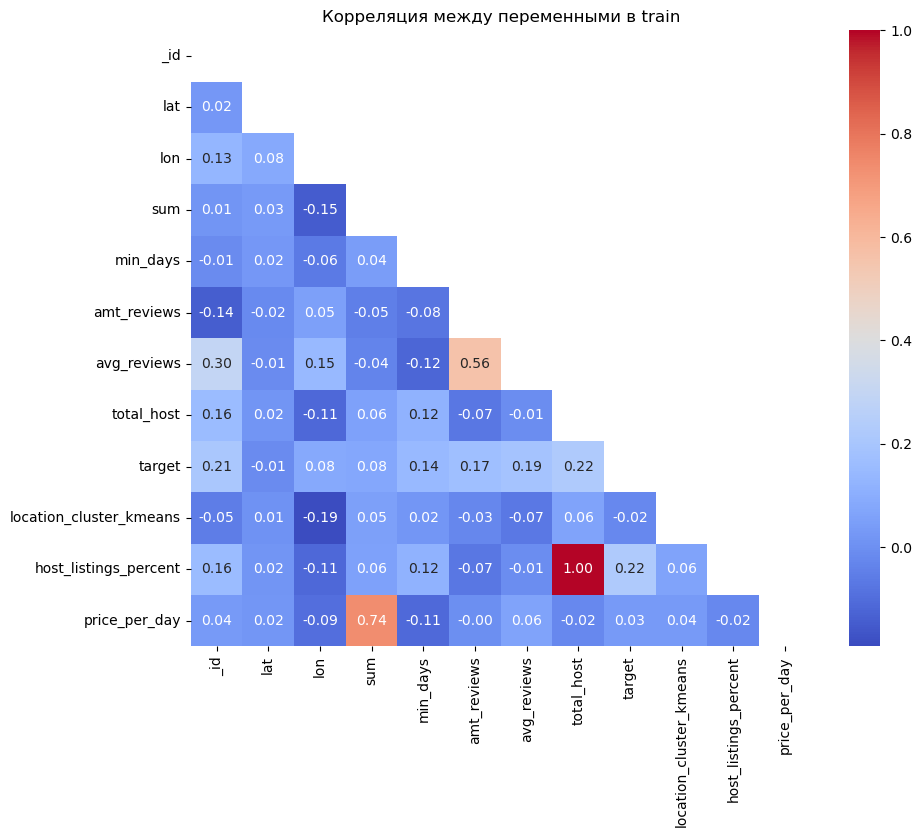

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


corr_matrix = train.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция между переменными в train")
plt.show()


Фичи host_listings_percent, last_review_year, sum сильно коррелируют между собой - поэтому удаляем эти фичи из датасета.

In [85]:
train = train.drop(columns=['host_listings_percent'])
train = train.drop(columns=['sum'])
train = train.drop(columns=['host_name'])


In [50]:
train.isna().sum()

lat                           0
lon                           0
min_days                      0
amt_reviews                   0
avg_reviews                   0
total_host                    0
target                        0
days_since_review          7502
last_review_year           7502
last_review_month          7502
location_cluster_kmeans       0
price_per_day                 0
dtype: int64

In [10]:
train

,location_cluster,location,lat,lon,type_house,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_year,last_review_month,location_cluster_kmeans,price_per_day
0,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,2,5,2.88,1,334,2093.0,2019.0,7.0,13,116.666667
1,Brooklyn,Clinton Hill,40.69172,-73.96934,Shared room,5,8,0.13,1,0,3686.0,2015.0,2.0,7,6.666667
2,Manhattan,Upper West Side,40.77673,-73.98011,Entire home/apt,5,0,0.72,1,0,NaN,NaN,NaN,11,33.333333
3,Manhattan,Harlem,40.81530,-73.95080,Private room,2,18,0.64,1,0,2338.0,2018.0,11.0,3,21.666667
4,Brooklyn,Bushwick,40.70230,-73.92935,Private room,2,26,0.76,1,155,2107.0,2019.0,6.0,2,33.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Manhattan,Harlem,40.81264,-73.94231,Private room,1,3,0.46,1,0,2280.0,2019.0,1.0,3,30.000000
36667,Brooklyn,Boerum Hill,40.68554,-73.98471,Entire home/apt,2,10,0.18,1,0,3126.0,2016.0,9.0,7,88.333333
36668,Brooklyn,Williamsburg,40.71852,-73.94165,Entire home/apt,365,0,0.72,1,363,NaN,NaN,NaN,9,0.655738
36669,Brooklyn,South Slope,40.66617,-73.98862,Private room,2,15,2.34,1,91,2112.0,2019.0,6.0,7,30.000000


Работа с категориальными и числовыми признаками:
Категориальные признаки передаются непосредственно в модель через параметр cat_features, а числовые признаки масштабируются с использованием RobustScaler для устойчивости к выбросам.

In [86]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

In [87]:
numeric_columns = ['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'days_since_review', 'last_review_month', 'price_per_day']
train_scaled= train.copy()
train[numeric_columns] = scaler.fit_transform(train[numeric_columns])
train

,location_cluster,location,lat,lon,type_house,min_days,amt_reviews,avg_reviews,total_host,target,days_since_review,last_review_year,last_review_month,location_cluster_kmeans,price_per_day
0,Queens,Neponsit,-2.063687,2.066447,Entire home/apt,-0.25,0.000000,1.661538,0.0,334,-0.140805,2019.0,0.5,13,2.504762
1,Brooklyn,Clinton Hill,-0.429548,-0.292538,Shared room,0.50,0.130435,-0.453846,0.0,0,4.436782,2015.0,-2.0,7,-0.638095
2,Manhattan,Upper West Side,0.732267,-0.521176,Entire home/apt,0.50,-0.217391,0.000000,0.0,0,NaN,NaN,NaN,11,0.123810
3,Manhattan,Harlem,1.259396,0.101051,Private room,-0.25,0.565217,-0.061538,0.0,0,0.563218,2018.0,2.5,3,-0.209524
4,Brooklyn,Bushwick,-0.284953,0.556417,Private room,-0.25,0.913043,0.030769,0.0,155,-0.100575,2019.0,0.0,2,0.114286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36666,Manhattan,Harlem,1.223042,0.281286,Private room,-0.50,-0.086957,-0.200000,0.0,0,0.396552,2019.0,-2.5,3,0.028571
36667,Brooklyn,Boerum Hill,-0.514008,-0.618830,Entire home/apt,-0.25,0.217391,-0.415385,0.0,0,2.827586,2016.0,1.5,7,1.695238
36668,Brooklyn,Williamsburg,-0.063277,0.295298,Entire home/apt,90.50,-0.217391,0.000000,0.0,363,NaN,NaN,NaN,9,-0.809836
36669,Brooklyn,South Slope,-0.778734,-0.701836,Private room,-0.25,0.434783,1.246154,0.0,91,-0.086207,2019.0,0.0,7,0.028571


In [88]:
numeric_columns = ['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 
                   'total_host', 'days_since_review', 'last_review_month', 'price_per_day']
cat_columns = ['location_cluster', 'location', 'type_house']
scaler = StandardScaler()
train_scaled = train.copy()
train_scaled[numeric_columns] = scaler.fit_transform(train_scaled[numeric_columns])

In [89]:
train_scaled['target_bin'] = pd.qcut(train_scaled['target'], q=10, duplicates='drop', labels=False)


In [90]:

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cats = pd.DataFrame(encoder.fit_transform(train_scaled[cat_columns]),
                            index=train_scaled.index,
                            columns=encoder.get_feature_names_out(cat_columns))

In [91]:
features = pd.concat([train_scaled[numeric_columns], encoded_cats], axis=1)

In [92]:
X = features.copy()
y = train_scaled['target']


In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42,
    stratify=train_scaled['target_bin']
)


In [94]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)


In [20]:
y_train_bins = pd.qcut(y_train, q=10, duplicates='drop', labels=False).astype(int)

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [22]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

base_models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42),
    'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=0),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42)
}

oof_preds = {name: np.zeros(len(y_train)) for name in base_models.keys()}
test_preds = {name: np.zeros(len(X_test)) for name in base_models.keys()}

fold_preds = {name: [] for name in base_models.keys()}
fold_errors = {name: [] for name in base_models.keys()}

In [23]:

X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)


In [24]:
for name, model in base_models.items():
    print(f'Обучение модели {name}...')
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_bins)):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        oof_preds[name][val_idx] = preds
        
        fold_preds[name].append(model.predict(X_test))
        
        fold_error = mean_squared_error(y_val, preds)
        fold_errors[name].append(fold_error)
        
    test_preds[name] = np.mean(fold_preds[name], axis=0)
    mse_model = mean_squared_error(y_train, oof_preds[name])
    print(f'{name} MSE (oof): {mse_model:.4f}')

Обучение модели RandomForest...
RandomForest MSE (oof): 10767.0537
Обучение модели XGBoost...
XGBoost MSE (oof): 10724.1066
Обучение модели LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1863
[LightGBM] [Info] Number of data points in the train set: 19655, number of used features: 115
[LightGBM] [Info] Start training from score 112.824472
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1859
[LightGBM] [Info] Number of data points in the train set: 19655, number of used features: 114
[LightGBM] [Info] Start training from score 112.709387
[LightGBM] [Info] Auto-choosin

In [25]:
stacked_train = pd.DataFrame(oof_preds)
stacked_test = pd.DataFrame(test_preds)

meta_model = RandomForestRegressor(n_estimators=100, random_state=42)
meta_model.fit(stacked_train, y_train)
stacking_preds = meta_model.predict(stacked_test)
stacking_mse = mean_squared_error(y_test, stacking_preds)
print(f'Stacking MSE: {stacking_mse:.4f}')

Stacking MSE: 10492.9543


RandomForest MSE на тесте: 10335.2789
XGBoost MSE на тесте: 10145.9424
LightGBM MSE на тесте: 10277.7259
CatBoost MSE на тесте: 10164.1748
HistGradientBoosting MSE на тесте: 10296.1602


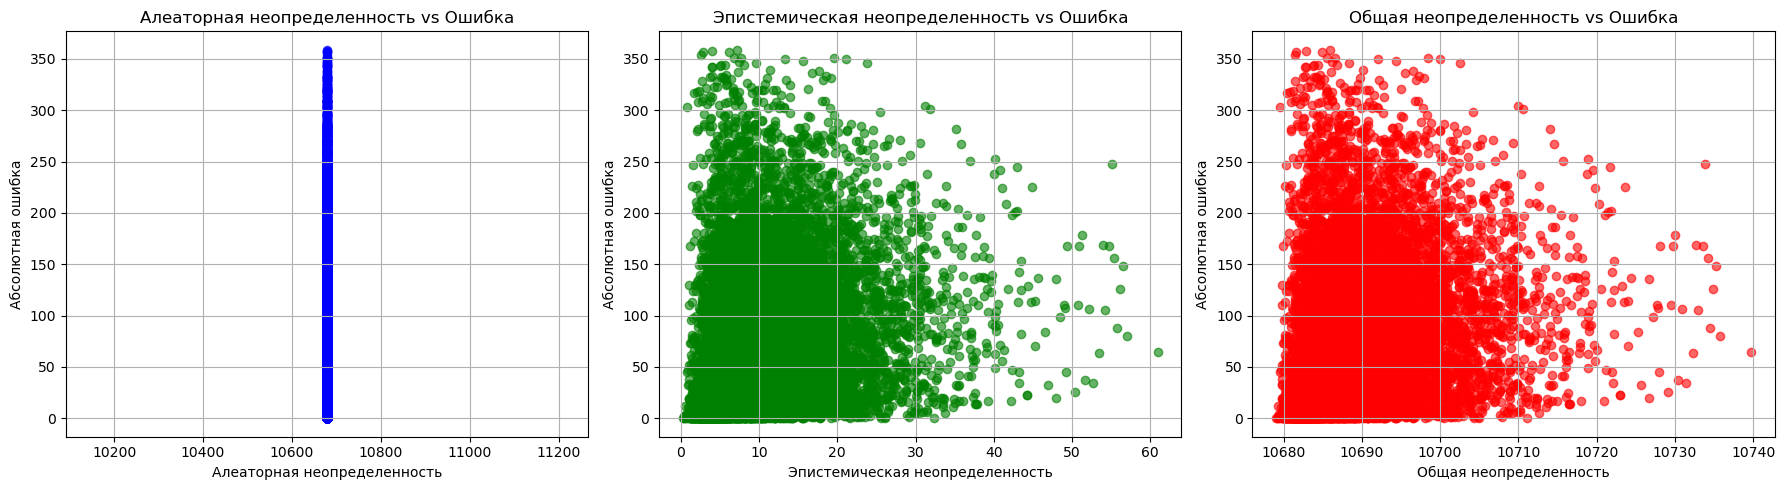

In [ ]:
base_preds_test = np.column_stack([test_preds[name] for name in base_models.keys()])
epistemic_uncertainty = np.std(base_preds_test, axis=1)

aleatoric_uncertainty_model = {name: np.mean(fold_errors[name]) for name in base_models.keys()}
aleatoric_uncertainty = np.full(len(X_test), np.mean(list(aleatoric_uncertainty_model.values())))
total_uncertainty = epistemic_uncertainty + aleatoric_uncertainty

mse_test = {}
for name in base_models.keys():
    mse_test[name] = mean_squared_error(y_test, test_preds[name])
    print(f'{name} MSE на тесте: {mse_test[name]:.4f}')

abs_error = np.abs(y_test - stacking_preds)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(aleatoric_uncertainty, abs_error, alpha=0.6, color='blue')
axs[0].set_xlabel('Алеаторная неопределенность')
axs[0].set_ylabel('Абсолютная ошибка')
axs[0].set_title('Алеаторная неопределенность vs Ошибка')
axs[0].grid(True)

axs[1].scatter(epistemic_uncertainty, abs_error, alpha=0.6, color='green')
axs[1].set_xlabel('Эпистемическая неопределенность')
axs[1].set_ylabel('Абсолютная ошибка')
axs[1].set_title('Эпистемическая неопределенность vs Ошибка')
axs[1].grid(True)

axs[2].scatter(total_uncertainty, abs_error, alpha=0.6, color='red')
axs[2].set_xlabel('Общая неопределенность')
axs[2].set_ylabel('Абсолютная ошибка')
axs[2].set_title('Общая неопределенность vs Ошибка')
axs[2].grid(True)

plt.tight_layout()
plt.show()


По этим трем графикам можно заметить следующее:

1. **Алеаторная неопределенность**  
   - Получилась практически вертикальная линия. Это происходит из-за того, что используется одно усредненное значение ошибки  в качестве алеаторной неопределенности для каждого тестового примера.    
   - В таком виде этот график не показывает корреляции с ошибкой, так как нет вариации.

2. **Эпистемическая неопределенность**  
   - Здесь по оси X видно существенное разнообразие значений, поскольку эпистемическая неопределенность рассчитывается как стандартное отклонение предсказаний разных базовых моделей для каждого тестового примера.   
   - Если бы существовала сильная корреляция между эпистемической неопределенностью и ошибкой, то точки лежали бы по диагоналию Однако, облако выглядит равномерно, значит в целом эпистемическая неопределенность не является сильным предиктором реальной ошибки.

3. **Общая неопределенность**  
   - Поскольку алеаторная часть почти константна, общая неопределенность сдвигает эпистемическую ось X на некоторое постоянное значение.  Данное облако сохраняет поведение эпистемической неопределенности.


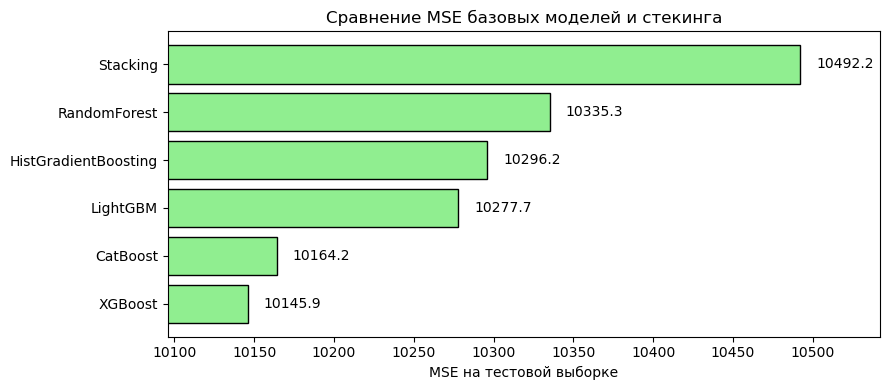

In [ ]:
models = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting', 'Stacking']
mse_values = [10335.2789, 10145.9424, 10277.7259, 10164.1748, 10296.1602, 10492.1778]

models_mse = sorted(zip(models, mse_values), key=lambda x: x[1])
sorted_models, sorted_mse = zip(*models_mse)

plt.figure(figsize=(9, 4))

bars = plt.barh(sorted_models, sorted_mse, color='lightgreen', edgecolor='black')

plt.xlabel('MSE на тестовой выборке')
plt.title('Сравнение MSE базовых моделей и стекинга')

min_mse, max_mse = min(sorted_mse), max(sorted_mse)
plt.xlim(min_mse - 50, max_mse + 50)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2,
             f'{width:.1f}', ha='left', va='center')

plt.tight_layout()
plt.show()


Получилось, что с помощью стекинга метрика оказалась выше, это могло произойти по следуюшим причинам:

1. **Переобучение мета-модели:**  
   - Мета-модель переобучается на out-of-fold данных, и как следствие, плохо обобщается на тестовой выборке.

2. **Неподходящий выбор мета-модели:**  
   -  Выбранная мета-модель менее мощная или плохо настроенная, не сможет оптимально комбинировать предсказания базовых моделей, что приводит к ухудшению результатов.

3. **Однородность базовых моделей:**  
   - Базовые модели дают очень похожие предсказания, их комбинация не дает значительного прироста, а дополнительный слой может только добавить шум.

Таким образом, хотя цель стекинга — объединить сильные стороны базовых моделей и улучшить итоговый результат, в некоторых случаях выбранная стратегия объединения может оказаться не оптимальной, что приводит к увеличению MSE по сравнению с лучшими отдельными моделями.

In [95]:
test = pd.read_csv('test.csv')

def preprocess_data_test(df):
   
    df['host_name'].fillna('unknown', inplace=True)
    df['amt_reviews'].fillna(0, inplace=True)
    df['avg_reviews'].fillna(df['avg_reviews'].median(), inplace=True)
    
  
    df['last_dt'] = pd.to_datetime(df['last_dt'])
    df['days_since_review'] = (datetime.now() - df['last_dt']).dt.days
    df['last_review_year'] = df['last_dt'].dt.year
    df['last_review_month'] = df['last_dt'].dt.month
    
 
    
  
    df.drop(['_id', 'name', 'last_dt'], axis=1, inplace=True)
    
    return df

test = preprocess_data_test(test)


# Применяем функцию add_features для test с уже обученной моделью
test = add_features(test, kmeans_model)

/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_58115/2085584917.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna('unknown', inplace=True)
/var/folders/rm/c6dtgnt92mncnb60whf8_fqm0000gn/T/ipykernel_58115/2085584917.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

In [96]:
test = test.drop(columns=['host_listings_percent'])
test = test.drop(columns=['last_review_year', 'sum'])

In [97]:
numeric_columns = ['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host', 'days_since_review', 'last_review_month', 'price_per_day']
test_scaled= test.copy()
test[numeric_columns] = scaler.transform(test[numeric_columns])

numeric_columns = ['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 
                   'total_host', 'days_since_review', 'last_review_month', 'price_per_day']
cat_columns = ['location_cluster', 'location', 'type_house']

test_scaled = test.copy()
test_scaled[numeric_columns] = scaler.transform(test_scaled[numeric_columns])

encoded_cats = pd.DataFrame(encoder.transform(test_scaled[cat_columns]),
                            index=test_scaled.index,
                            columns=encoder.get_feature_names_out(cat_columns))
features = pd.concat([test_scaled[numeric_columns], encoded_cats], axis=1)
from sklearn.impute import SimpleImputer



In [98]:
training_columns = features.columns 
training_columns

Index(['lat', 'lon', 'min_days', 'amt_reviews', 'avg_reviews', 'total_host',
       'days_since_review', 'last_review_month', 'price_per_day',
       'location_cluster_Bronx',
       ...
       'location_Williamsburg', 'location_Willowbrook',
       'location_Windsor Terrace', 'location_Woodhaven', 'location_Woodlawn',
       'location_Woodrow', 'location_Woodside', 'type_house_Entire home/apt',
       'type_house_Private room', 'type_house_Shared room'],
      dtype='object', length=237)

In [99]:

features.columns = features.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)


In [100]:
X_test_imputed = pd.DataFrame(imputer.transform(features), columns=features.columns)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- location_Arden_Heights
- location_Bath_Beach
- location_Battery_Park_City
- location_Bay_Ridge
- location_Bay_Terrace
- ...
Feature names seen at fit time, yet now missing:
- location_Arden Heights
- location_Bath Beach
- location_Battery Park City
- location_Bay Ridge
- location_Bay Terrace
- ...


In [102]:
stacking_preds = meta_model.predict(features)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- amt_reviews
- avg_reviews
- days_since_review
- last_review_month
- lat
- ...
Feature names seen at fit time, yet now missing:
- CatBoost
- HistGradientBoosting
- LightGBM
- RandomForest
- XGBoost
